# Tutorial 1.2 — Part 2: Introduction to day-ahead load forecasting

This tutorial complements the [data-quality and imputation tutorial](tutorial_1_2_time_series_forecasting.ipynb) (each notebook is independent). Here we use the original, complete 2007 GEFCom2012 aggregate demand series.

The aim is to practise the steps used in the assessment: construct predictors, split data in time order, fit a model, generate forecasts and interpret errors. Work through one method at a time. Use ordinary notebook cells for forecasting. Construct reusable functions for error metrics.

By the end, you should be able to:

- issue a forecast for the next 24 hours and move the origin forward by one day;
- implement persistence and daily/weekly seasonal-naïve forecasts;
- construct and visualise load-lag and calendar predictors for linear regression;
- calculate RMSE, MAE and MAPE and compare forecasts fairly.

Allow approximately 75–90 minutes: setup/origins 10 minutes, benchmarks 20 minutes, linear features/model 30 minutes, metrics/plots 20 minutes and discussion 5 minutes. Replace the **TODOs** and remove their NotImplementedError once each step is complete.

## 1. Setup and data

Use Z21, the aggregate load across 20 zones, measured in MW. We restrict this tutorial to the complete year 2007. Loading and checking the data are supplied so you can focus on forecasting.

Source: Hong, T., Pinson, P. and Fan, S. (2014), ‘Global Energy Forecasting Competition 2012’, *International Journal of Forecasting*, 30(2), pp. 357–363. [Dataset paper](https://doi.org/10.1016/j.ijforecast.2013.07.001). Further provenance is in [the data README](data/tutorial_1_2/README.md).

Run from the repository root. No other notebook or local Python helper is needed.

In [152]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

In [153]:
DATA_PATH = Path("data") / "tutorial_1_2" / "load_data_full.csv"
load_data = pd.read_csv(DATA_PATH, index_col=0, parse_dates=[0]).sort_index()
load_data.index.name = "timestamp"
if not load_data.index.is_unique:
    raise ValueError("Resolve duplicate timestamps before constructing load lags.")

load_series = load_data.loc["2007", "Z21"].copy()
expected_index = pd.date_range("2007-01-01 00:00", "2007-12-31 23:00", freq="h", name="timestamp")
if not load_series.index.equals(expected_index):
    raise ValueError("The selected 2007 series must contain every hourly timestamp.")
if not np.isfinite(load_series.to_numpy()).all() or (load_series <= 0).any():
    raise ValueError("This exercise requires complete, finite, positive demand observations.")
print(f"Loaded {len(load_series):,} complete hourly observations from 2007.")

Loaded 8,760 complete hourly observations from 2007.


## 2. Forecast origins and chronological split

The **forecast origin** is the time when we issue a forecast. Let $D$ denote the day we want to forecast; $D-1$ is the preceding day. For example, if $D$ is 1 October, then $D-1$ is 30 September.

At **23:00 on day $D-1$**, issue forecasts for **00:00–23:00 on day $D$**. The first target is one hour after the origin; the last is 24 hours after it. Move the origin forward **24 hours**, observe the completed day, then forecast the next day.

Training: **1 January–30 September 2007**. Testing: **1 October–31 December 2007**, a three-month test period. Forecast the entire test set and use one week for illustration. Fit linear regression once on training data and keep its coefficients fixed; update the available observations at each new origin.

![Daily forecast origins](images/tutorial_1_2/rolling_day_ahead_schematic_v2.png)

Each square represents one day. Blue days have been observed; orange is the next forecast day. Each row shows the next daily origin.

This is a simplified end-of-day setting. A forecast issued earlier on the preceding day would have less recent demand information available.

In [154]:
# Fit models on January–September; evaluate on October–December.
TRAIN_START, TRAIN_END = "2007-01-01 00:00", "2007-09-30 23:00"
TEST_START, TEST_END = "2007-10-01 00:00", "2007-12-31 23:00"
PLOT_START, PLOT_END = "2007-10-08 00:00", "2007-10-14 23:00"

training_load = load_series.loc[TRAIN_START:TRAIN_END]
test_actual = load_series.loc[TEST_START:TEST_END]
test_index = test_actual.index
# normalize() sets each target to midnight; subtract one hour to find its origin.
forecast_origins = pd.Series(
    test_index.normalize() - pd.Timedelta(hours=1), index=test_index, name="origin"
)
forecasts = pd.DataFrame(index=test_index)

assert len(test_actual) == 2208 and len(test_actual) % 24 == 0
assert forecast_origins.iloc[0] == training_load.index[-1]
print(f"Training observations: {len(training_load):,}")
print(f"Test observations: {len(test_actual):,}, covering {len(test_actual) // 24} daily origins.")
print(f"First origin: {forecast_origins.iloc[0]}; next origin: {forecast_origins.iloc[24]}")

Training observations: 6,552
Test observations: 2,208, covering 92 daily origins.
First origin: 2007-09-30 23:00:00; next origin: 2007-10-01 23:00:00


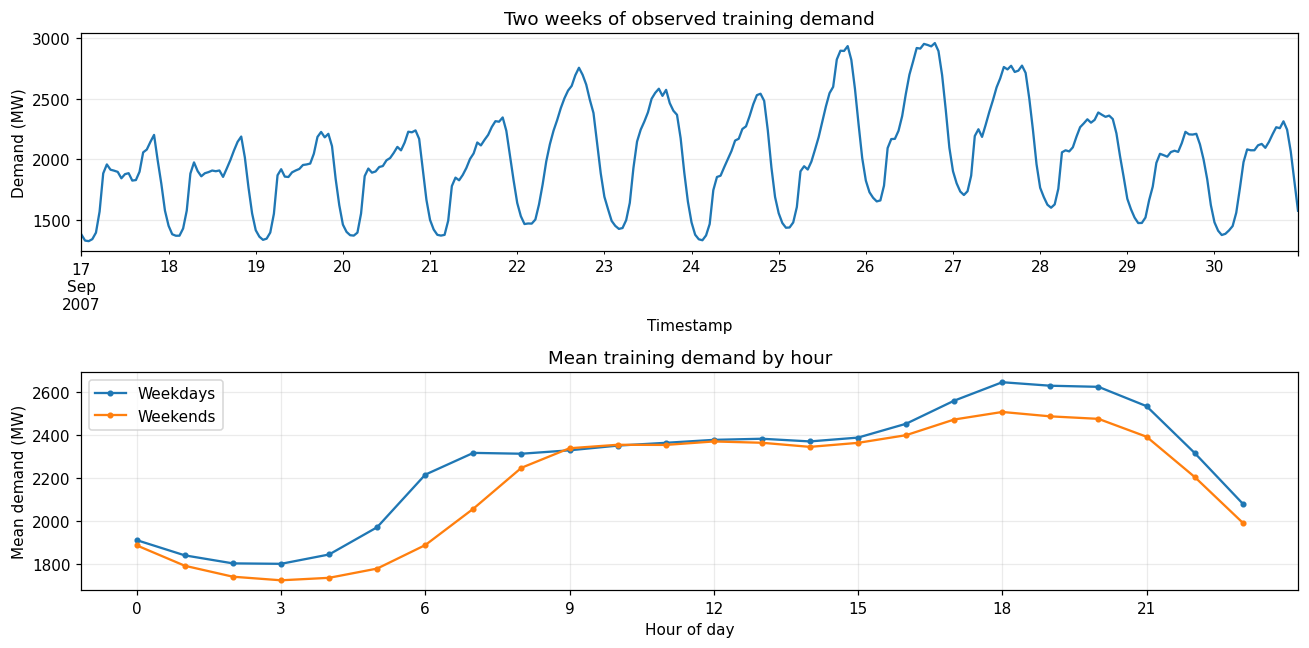

In [155]:
# Supplied exploratory plot: use training observations only.
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
training_load.loc["2007-09-17":TRAIN_END].plot(ax=axes[0], color="tab:blue")
axes[0].set(title="Two weeks of observed training demand", xlabel="Timestamp", ylabel="Demand (MW)")
for label, selected in [("Weekdays", training_load.index.dayofweek < 5),
                        ("Weekends", training_load.index.dayofweek >= 5)]:
    group = training_load.loc[selected]
    # Average observations with the same clock hour and day type.
    group.groupby(group.index.hour).mean().plot(ax=axes[1], marker="o", markersize=3, label=label)
axes[1].set(title="Mean training demand by hour", xlabel="Hour of day", ylabel="Mean demand (MW)")
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend()
fig.tight_layout()
plt.show()

## 3. Persistence (naïve forecast)

### Task 1

Copy the last observation available at the origin to all 24 hours of the next day: $\hat y_{D,h}=y_{D-1,23}$, for $h=0,\ldots,23$.

For example, the observation at **30 September 23:00** supplies every forecast for **1 October 00:00–23:00**. Each forecast day is flat, but the copied value can change at the next daily origin.

Do **not** use the preceding observation at every test hour: that would be one-hour-ahead forecasting, not this day-ahead experiment.

### Read the daily loop

- `test_index[::24]` selects positions 0, 24, 48, …: midnight at the start of each forecast day.
- `day_start - pd.Timedelta(hours=1)` finds 23:00 on the preceding day.
- `pd.date_range(day_start, periods=24, freq="h")` creates the 24 **target** timestamps, from 00:00 to 23:00.

The slice chooses the start of each block; it does not skip those other hours when making predictions.

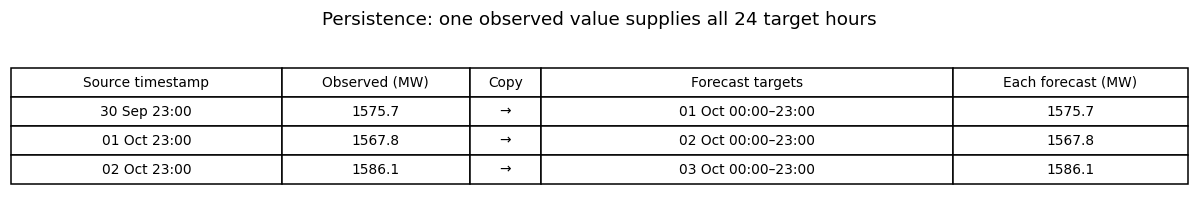

In [156]:
# Supplied illustration: actual GEFCom observations from 2007.
example_days = test_index[::24][:3]
example_sources = example_days - pd.Timedelta(hours=1)
example_values = load_series.loc[example_sources].round(1).to_numpy()
row_map = pd.DataFrame({
    "Source timestamp": example_sources.strftime("%d %b %H:%M"),
    "Observed (MW)": example_values,
    "Copy": ["→"] * 3,
    "Forecast targets": example_days.strftime("%d %b") + " 00:00–23:00",
    "Each forecast (MW)": example_values,
})

fig, ax = plt.subplots(figsize=(11, 2.1))
ax.axis("off")
ax.set_title("Persistence: one observed value supplies all 24 target hours", pad=12)
row_table = ax.table(cellText=row_map.to_numpy(), colLabels=row_map.columns,
                     loc="center", cellLoc="center", colWidths=[0.23, 0.16, 0.06, 0.35, 0.20])
row_table.auto_set_font_size(False)
row_table.set_fontsize(9)
row_table.scale(1, 1.7)
fig.tight_layout()
plt.show()

In [157]:
naive_predictions = pd.Series(index=test_index, dtype=float)
for day_start in test_index[::24]:  # One midnight per forecast day.
    origin = day_start - pd.Timedelta(hours=1)  # Previous day at 23:00.
    day_index = pd.date_range(day_start, periods=24, freq="h")  # Targets 00:00–23:00.
    naive_predictions.loc[day_index] = load_series.loc[origin]
forecasts["Naïve"] = naive_predictions

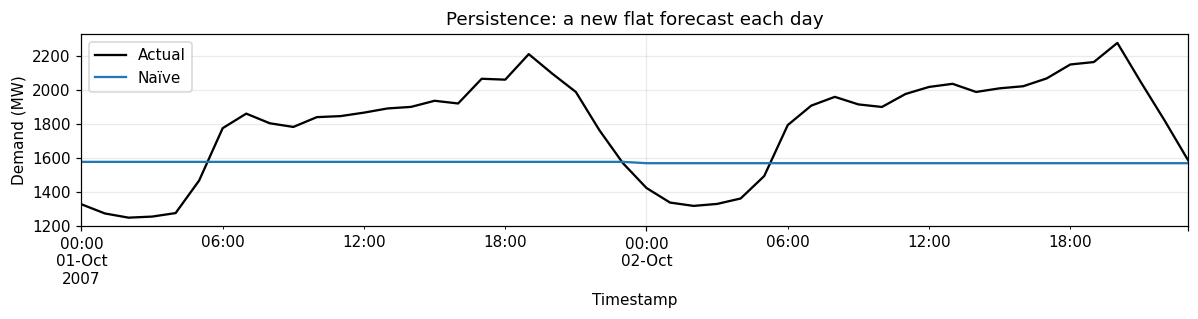

In [158]:
# Supplied plot: the first two daily forecasts.
fig, ax = plt.subplots(figsize=(11, 3))
test_actual.iloc[:48].plot(ax=ax, color="black", label="Actual")
forecasts["Naïve"].iloc[:48].plot(ax=ax, label="Naïve")
ax.set(title="Persistence: a new flat forecast each day", xlabel="Timestamp", ylabel="Demand (MW)")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Daily seasonal-naïve forecast

### Task 2

Copy demand from the same hour of the preceding day: $\hat y_{D,h}=y_{D-1,h}$.

Here $h$ is the target hour (0–23), $y$ is an observation and $\hat y$ is a forecast. For example, **30 September 01:00** supplies the forecast for **1 October 01:00**. Unlike persistence, different target hours copy different observations.

On the complete hourly index, `shift(24)` aligns each source observation with its target 24 hours later. Select test timestamps **after shifting**, so the first test day still has access to September observations. All source values are known at the preceding day's 23:00 origin.

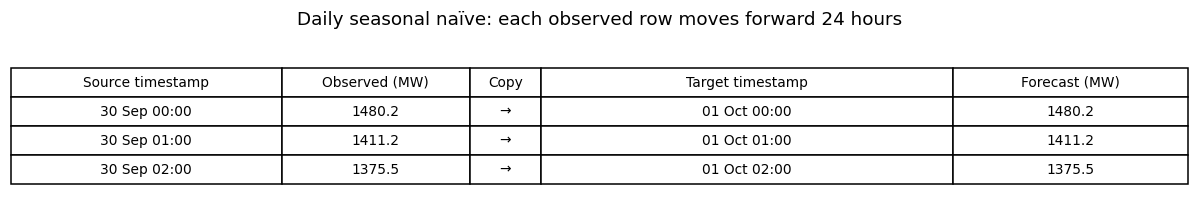

In [159]:
# Supplied illustration: actual GEFCom observations from 2007.
example_targets = test_index[:3]
example_sources = example_targets - pd.Timedelta(hours=24)
example_values = load_series.loc[example_sources].round(1).to_numpy()
row_map = pd.DataFrame({
    "Source timestamp": example_sources.strftime("%d %b %H:%M"),
    "Observed (MW)": example_values,
    "Copy": ["→"] * 3,
    "Target timestamp": example_targets.strftime("%d %b %H:%M"),
    "Forecast (MW)": example_values,
})

fig, ax = plt.subplots(figsize=(11, 2.1))
ax.axis("off")
ax.set_title("Daily seasonal naïve: each observed row moves forward 24 hours", pad=12)
row_table = ax.table(cellText=row_map.to_numpy(), colLabels=row_map.columns,
                     loc="center", cellLoc="center", colWidths=[0.23, 0.16, 0.06, 0.35, 0.20])
row_table.auto_set_font_size(False)
row_table.set_fontsize(9)
row_table.scale(1, 1.7)
fig.tight_layout()
plt.show()

In [160]:
daily_predictions = load_series.shift(24).loc[test_index]
forecasts["Seasonal naive (24 h)"] = daily_predictions

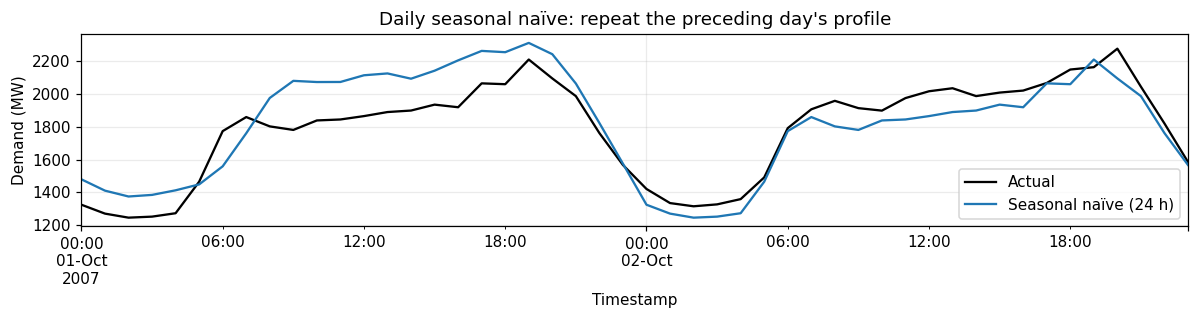

In [161]:
fig, ax = plt.subplots(figsize=(11, 3))
test_actual.iloc[:48].plot(ax=ax, color="black", label="Actual")
forecasts["Seasonal naive (24 h)"].iloc[:48].plot(ax=ax, label="Seasonal naïve (24 h)")
ax.set(title="Daily seasonal naïve: repeat the preceding day's profile", xlabel="Timestamp", ylabel="Demand (MW)")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Weekly seasonal-naïve forecast

### Task 3

Copy demand from the same hour and weekday one week earlier: $\hat y_{D,h}=y_{D-7,h}$.

For example, **24 September 01:00** supplies the forecast for **1 October 01:00**. Use a shift of 168 hours ($7\times24$) on the original series before selecting test rows.

Later forecasts may use earlier **observed** test demand, because it is already known at their own daily origins. Neither seasonal method uses future observations or previous forecasts.

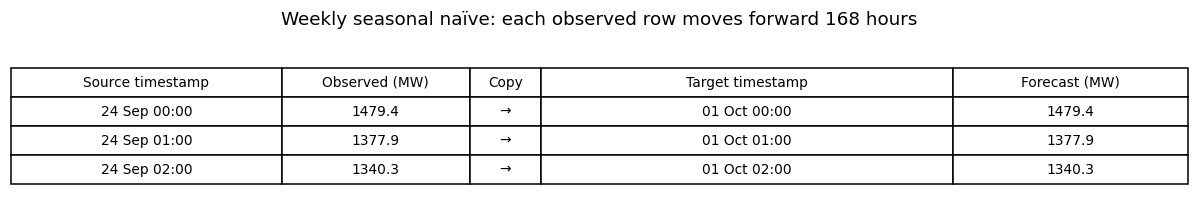

In [162]:
# Supplied illustration: actual GEFCom observations from 2007.
example_targets = test_index[:3]
example_sources = example_targets - pd.Timedelta(hours=168)
example_values = load_series.loc[example_sources].round(1).to_numpy()
row_map = pd.DataFrame({
    "Source timestamp": example_sources.strftime("%d %b %H:%M"),
    "Observed (MW)": example_values,
    "Copy": ["→"] * 3,
    "Target timestamp": example_targets.strftime("%d %b %H:%M"),
    "Forecast (MW)": example_values,
})

fig, ax = plt.subplots(figsize=(11, 2.1))
ax.axis("off")
ax.set_title("Weekly seasonal naïve: each observed row moves forward 168 hours", pad=12)
row_table = ax.table(cellText=row_map.to_numpy(), colLabels=row_map.columns,
                     loc="center", cellLoc="center", colWidths=[0.23, 0.16, 0.06, 0.35, 0.20])
row_table.auto_set_font_size(False)
row_table.set_fontsize(9)
row_table.scale(1, 1.7)
fig.tight_layout()
plt.show()

In [163]:
weekly_predictions = load_series.shift(168).loc[test_index]
forecasts["Seasonal naive (168 h)"] = weekly_predictions

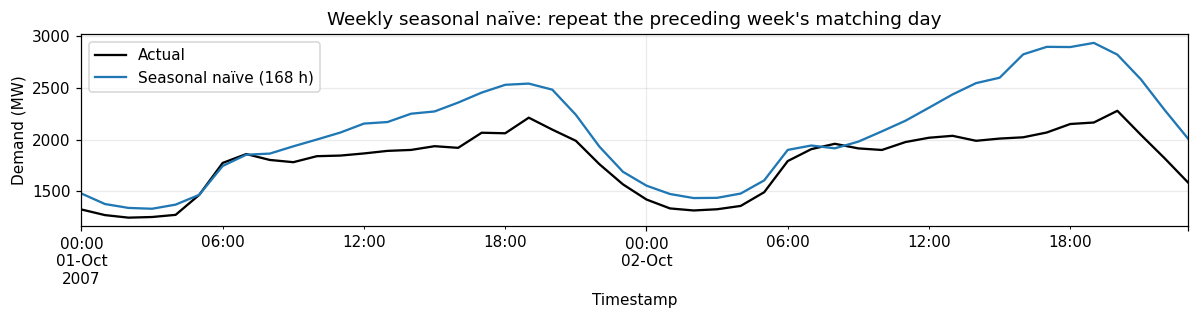

In [164]:
fig, ax = plt.subplots(figsize=(11, 3))
test_actual.iloc[:48].plot(ax=ax, color="black", label="Actual")
forecasts["Seasonal naive (168 h)"].iloc[:48].plot(ax=ax, label="Seasonal naïve (168 h)")
ax.set(title="Weekly seasonal naïve: repeat the preceding week's matching day", xlabel="Timestamp", ylabel="Demand (MW)")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Linear regression

### Task 4a: explore potential predictors

A linear model combines predictors instead of copying one historical observation. Before choosing its inputs, examine the **training** demand only.

Start with the autocorrelation plot to find important lags. Then compare current demand $y_t$ with $y_{t-1}$, $y_{t-24}$ and $y_{t-168}$ in the scatter plots. Which relationship is strongest? What do the daily and weekly peaks suggest about potential predictors?

These plots are exploratory. A useful predictor must also be available when we issue the forecast.

### Autocorrelation and lag relationships

Autocorrelation measures how closely a series follows its own past values. The supplied plot shows the first 300 hourly lags; values near 1 indicate a strong positive relationship.

The coloured dashed lines mark **1 hour**, **24 hours (one day)** and **168 hours (one week)**. Compare these lags with the repeated daily peaks. The grey horizontal lines are approximate 95% (solid) and 99% (dashed) reference limits for an uncorrelated series, not forecast intervals.

Then examine the three lag relationships in the scatter plots. Strong association alone does not make a predictor available at the forecast origin.

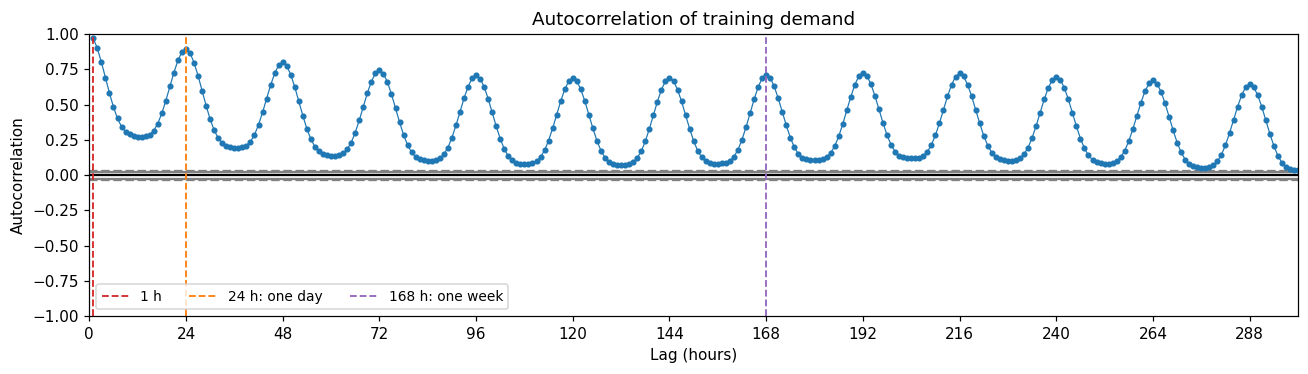

In [165]:
# Supplied pandas plot: use training observations only.
fig, ax = plt.subplots(figsize=(12, 3.5))
pd.plotting.autocorrelation_plot(training_load, ax=ax, color="tab:blue",
                                marker="o", markersize=3, linewidth=0.8)
for lag, label, colour in [(1, "1 h", "tab:red"), (24, "24 h: one day", "tab:orange"),
                            (168, "168 h: one week", "tab:purple")]:
    ax.axvline(lag, color=colour, linestyle="--", linewidth=1.2, label=label)
ax.set(title="Autocorrelation of training demand", xlabel="Lag (hours)",
       ylabel="Autocorrelation", xlim=(0, 300), ylim=(-1, 1))
ax.set_xticks([0, 24, 48, 72, 96, 120, 144, 168, 192, 216, 240, 264, 288])
ax.legend(loc="lower left", ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

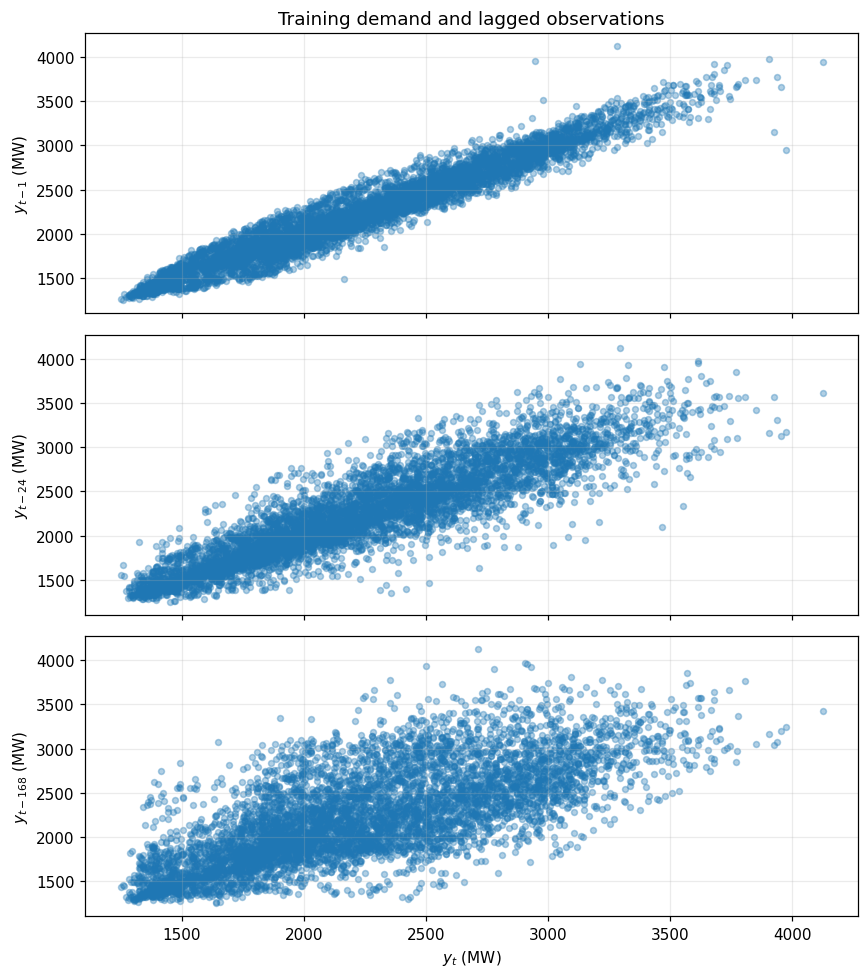

In [166]:
# Lag exploratory plot
lagged_load = pd.DataFrame(index=training_load.index)
lagged_load["current"] = training_load
for lag in [1, 24, 168]:
    lagged_load[f"lag_{lag}"] = training_load.shift(lag)
lagged_load = lagged_load.dropna()

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True, sharey=True)
for ax, lag in zip(axes, [1, 24, 168]):
    ax.scatter(lagged_load["current"], lagged_load[f"lag_{lag}"],
               s=15, alpha=0.35, color="tab:blue")
    ax.set_ylabel(rf"$y_{{t-{lag}}}$ (MW)")
axes[0].set_title("Training demand and lagged observations")
axes[-1].set_xlabel(r"$y_t$ (MW)")
fig.tight_layout()
plt.show()

**Discuss before selecting predictors:** Why is $y_{t-1}$ unavailable as an observed predictor for most target hours in our day-ahead forecast, even if its relationship with $y_t$ is strong? What other predictors can be constructed from the ones that are available?

### Task 4b: select predictors and construct the model inputs

Use demand at $t-24$ and $t-168$, together with a weekend indicator, as the linear model's three inputs:

| Columns | Construction |
|---|---|
| load_lag_24, load_lag_168 | Demand 24 and 168 hours before the target |
| is_weekend | 1 for Saturday/Sunday, otherwise 0 |

Calendar variables refer to the **target** time and are known in advance. The load lags must be known at its **daily origin**. Construct lags on the complete hourly series before splitting, so test predictors retain their preceding training observations.

Inspect the selected training timestamps below. Initial lag NaNs mean that history before 1 January is not included; they are **not missing observations** in this complete 2007 series.

Then create the model inputs:

- `X_train`: training predictor rows, excluding rows with unavailable lags.
- `y_train`: actual training demand at those same timestamps.
- `X_test`: test predictors; retain every test target.

The first 168 training rows have an unavailable weekly lag. Drop those incomplete training rows only, not test observations.

In [167]:
index = load_series.index
features = pd.DataFrame(index=index)
features["load_lag_24"] = load_series.shift(24)
features["load_lag_168"] = load_series.shift(168)
features["is_weekend"] = (index.dayofweek >= 5).astype(int)

In [168]:
# Supplied examples: first day, first daily lag, a weekend and first weekly lag.
selected_times = ["2007-01-01 00:00", "2007-01-02 00:00", "2007-01-06 12:00",
                  "2007-01-08 00:00", "2007-01-08 01:00", "2007-01-08 02:00"]
feature_examples = features.loc[selected_times].copy()
feature_examples.insert(0, "Actual demand (MW)", load_series.loc[feature_examples.index])
display(feature_examples)

,Actual demand (MW),load_lag_24,load_lag_168,is_weekend
timestamp,,,,
2007-01-01 00:00:00,1859.682,NaN,NaN,0
2007-01-02 00:00:00,1814.531,1859.682,NaN,0
2007-01-06 12:00:00,1889.535,1975.246,NaN,1
2007-01-08 00:00:00,1679.220,1580.772,1859.682,0
2007-01-08 01:00:00,1546.498,1495.691,1761.282,0
2007-01-08 02:00:00,1541.381,1489.298,1660.252,0


In [169]:
# Remove only initial training rows whose past lags are unavailable.
X_train = features.loc[TRAIN_START:TRAIN_END].dropna()
# Match each predictor row to its actual training demand.
y_train = load_series.loc[X_train.index]
X_test = features.loc[TEST_START:TEST_END]

assert X_train.index.equals(y_train.index)
assert X_test.index.equals(test_actual.index) and X_test.notna().all().all()

print(f"Usable training rows: {len(X_train):,}; test rows: {len(X_test):,}")
print(f"Removed {len(features.loc[TRAIN_START:TRAIN_END]) - len(X_train)} initial training rows with missing lags.")
display(X_train.index[:5])

Usable training rows: 6,384; test rows: 2,208
Removed 168 initial training rows with missing lags.


DatetimeIndex(['2007-01-08 00:00:00', '2007-01-08 01:00:00',
               '2007-01-08 02:00:00', '2007-01-08 03:00:00',
               '2007-01-08 04:00:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)

### Task 4c: fit once and forecast

For a target timestamp $t$, the model is $\hat y_t=\beta_0+\beta_{24}y_{t-24}+\beta_{168}y_{t-168}+\beta_W I_t$.

- $\beta_0$ is the intercept, in MW.
- $\beta_{24}$ and $\beta_{168}$ are the weights on the daily and weekly load lags.
- $I_t$ is 1 on a weekend and 0 otherwise; $\beta_W$ is the weekend adjustment, in MW.

The model learns these parameters from training data by minimising squared errors. They are not probabilities and need not sum to 1.

Create LinearRegression, fit it on `X_train/y_train`, then predict `X_test`. Keep coefficients fixed during testing. Each test row already contains observations available at its own daily origin, so no retraining loop is needed. Project negative demand forecasts to zero **after** prediction.

In [170]:
linear_model = LinearRegression()  # Create the model.
linear_model.fit(X_train, y_train)  # Learn coefficients from training rows only.
linear_predictions = pd.Series(linear_model.predict(X_test), index=test_index)
forecasts["Linear regression"] = linear_predictions.clip(lower=0)

In [171]:
# Supplied: match fitted weights to predictor names.
display(pd.Series(linear_model.coef_, index=X_train.columns, name="Coefficient"))
print(f"Intercept (MW): {linear_model.intercept_:.3f}")

load_lag_24      0.774
load_lag_168     0.180
is_weekend     -69.035
Name: Coefficient, dtype: float64

Intercept (MW): 122.769


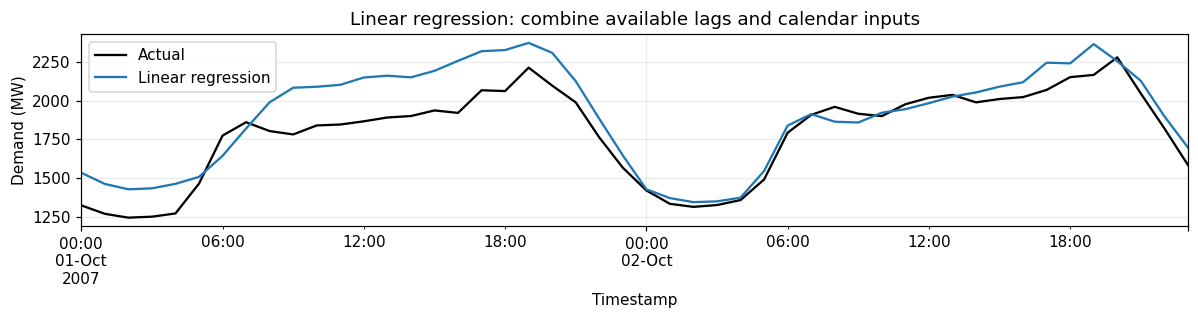

In [172]:
fig, ax = plt.subplots(figsize=(11, 3))
test_actual.iloc[:48].plot(ax=ax, color="black", label="Actual")
forecasts["Linear regression"].iloc[:48].plot(ax=ax, label="Linear regression")
ax.set(title="Linear regression: combine available lags and calendar inputs", xlabel="Timestamp", ylabel="Demand (MW)")
ax.legend()
fig.tight_layout()
plt.show()

## 7. Forecast error metrics

### Task 5: implement three reusable functions

Use actual minus forecast:

$$e_t=y_t-\hat y_t.$$

$$\mathrm{RMSE}=\sqrt{\frac{1}{N}\sum_t e_t^2},\qquad
\mathrm{MAE}=\frac{1}{N}\sum_t |e_t|,\qquad
\mathrm{MAPE}=\frac{100}{N}\sum_t\left|\frac{e_t}{y_t}\right|.$$

RMSE and MAE are in MW; MAPE is a percentage. RMSE gives large errors more weight, while MAPE measures error relative to demand.

Each function takes two pandas Series. Check identical lengths and timestamps **before** converting them to NumPy arrays. MAPE requires strictly positive actual demand here: raise an error for zero/non-positive values rather than adding a constant to its denominator.

In [173]:
def rmse(actual, forecast):
    """Return root mean squared error in MW. Both inputs are aligned pandas Series."""
    if len(actual) != len(forecast) or not actual.index.equals(forecast.index):
        raise ValueError("Actual and forecast must have the same length and timestamps.")
    actual_values = actual.to_numpy(dtype=float)
    forecast_values = forecast.to_numpy(dtype=float)
    error = actual_values - forecast_values
    return float(np.sqrt(np.mean(error ** 2)))

In [174]:
def mae(actual, forecast):
    """Return mean absolute error in MW. Both inputs are aligned pandas Series."""
    if len(actual) != len(forecast) or not actual.index.equals(forecast.index):
        raise ValueError("Actual and forecast must have the same length and timestamps.")
    actual_values = actual.to_numpy(dtype=float)
    forecast_values = forecast.to_numpy(dtype=float)
    error = actual_values - forecast_values
    return float(np.mean(np.abs(error)))

In [175]:
def mape(actual, forecast):
    """Return mean absolute percentage error (%). Both inputs are aligned pandas Series."""
    if len(actual) != len(forecast) or not actual.index.equals(forecast.index):
        raise ValueError("Actual and forecast must have the same length and timestamps.")
    actual_values = actual.to_numpy(dtype=float)
    forecast_values = forecast.to_numpy(dtype=float)
    if (actual_values <= 0).any():
        raise ValueError("MAPE requires strictly positive actual demand.")
    error = actual_values - forecast_values
    return float(100 * np.mean(np.abs(error / actual_values)))

## 8. Compare all four methods

### Task 6: create the comparison table

Score every method on the **same complete test set**, not just the displayed week. Put models in rows and RMSE, MAE and MAPE in columns. Do not tune the model or choose predictors using these test scores.

In [176]:
assert forecasts.index.equals(test_actual.index)

rows = []
for model in forecasts:
    prediction = forecasts[model]
    rows.append({"Model": model, "RMSE (MW)": rmse(test_actual, prediction),
                 "MAE (MW)": mae(test_actual, prediction), "MAPE (%)": mape(test_actual, prediction)})
comparison = pd.DataFrame(rows).set_index("Model")
display(comparison.round(3))

,RMSE (MW),MAE (MW),MAPE (%)
Model,,,
Naïve,342.700,279.872,12.607
Seasonal naive (24 h),224.468,163.991,7.346
Seasonal naive (168 h),363.382,270.876,12.122
Linear regression,207.330,155.355,6.990


## 9. Visualise forecasts and errors

### Forecasts for one week

Compare all four methods with actual demand over one test week. The comparison table above uses the full test set.

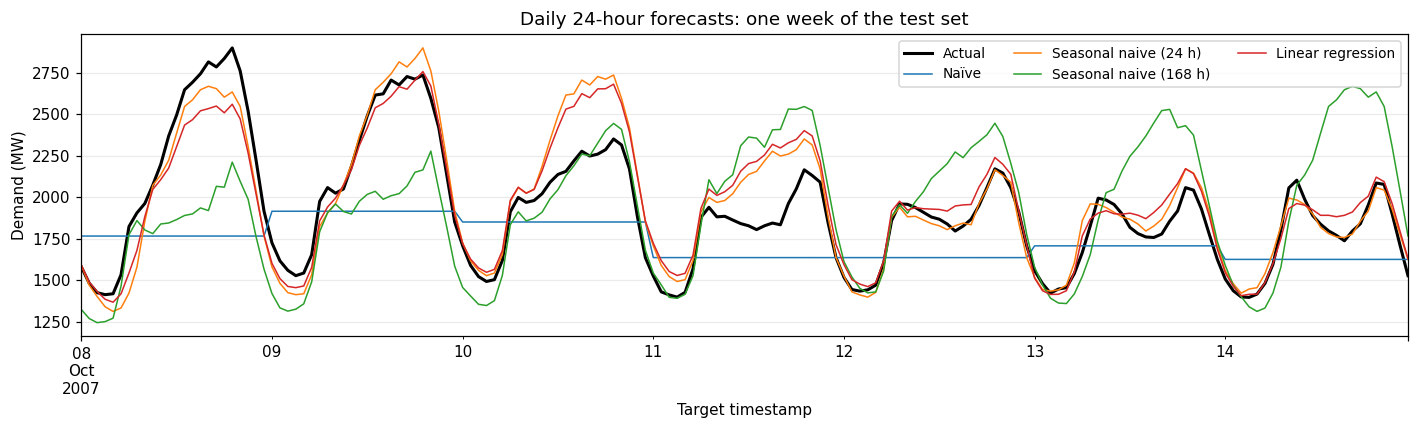

In [177]:
# Supplied plot: one readable week from the full test set.
fig, ax = plt.subplots(figsize=(13, 4))
test_actual.loc[PLOT_START:PLOT_END].plot(ax=ax, color="black", linewidth=2, label="Actual")
forecasts.loc[PLOT_START:PLOT_END].plot(ax=ax, linewidth=1)
ax.set(title="Daily 24-hour forecasts: one week of the test set",
       xlabel="Target timestamp", ylabel="Demand (MW)")
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

### Error distributions

Compare the signed errors for linear regression and daily seasonal naïve. Positive errors mean the forecast was below actual demand; negative errors mean it was above.

                       Naïve  Seasonal naive (24 h)  Seasonal naive (168 h)  \
timestamp                                                                     
2007-10-01 00:00:00 1575.706               1480.222                1479.413   
2007-10-01 01:00:00 1575.706               1411.209                1377.879   
2007-10-01 02:00:00 1575.706               1375.522                1340.329   
2007-10-01 03:00:00 1575.706               1385.292                1332.348   
2007-10-01 04:00:00 1575.706               1413.341                1372.181   

                     Linear regression  
timestamp                               
2007-10-01 00:00:00           1535.010  
2007-10-01 01:00:00           1463.300  
2007-10-01 02:00:00           1428.913  
2007-10-01 03:00:00           1435.037  
2007-10-01 04:00:00           1463.924  
Linear regression: mean error = 5.231, std error = 207.311
Seasonal naive (24 h): mean error = 5.240, std error = 224.457


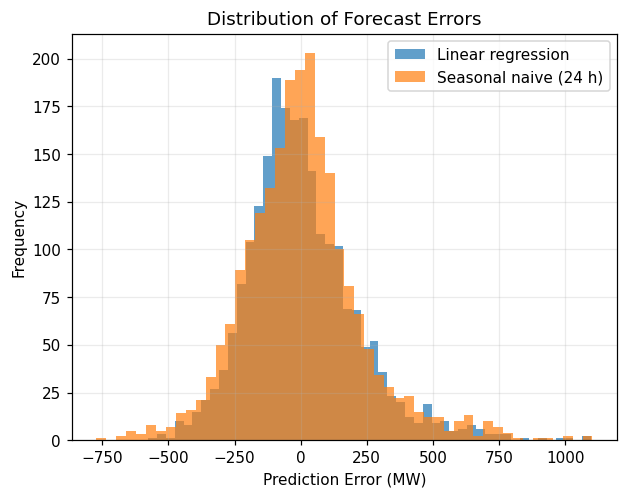

In [178]:
# Visualise some errors (actual minus forecast).

linear_errors = test_actual - forecasts["Linear regression"]
print(forecasts.head())
for method in ['Linear regression', 'Seasonal naive (24 h)']:
    errors = test_actual - forecasts[method]
    print(f"{method}: mean error = {errors.mean():.3f}, std error = {errors.std():.3f}")
    plt.hist(errors, bins=50, alpha=0.7, label = method)
    plt.xlabel("Prediction Error (MW)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Forecast Errors")
plt.legend()
plt.show()

### Errors by forecast hour

The supplied plot groups test targets by hour of day. Each score uses 92 observations—one from every test day. At the 23:00 origin, hour 0 has lead time 1 and hour 23 has lead time 24. This experiment cannot separate time-of-day effects from forecast-lead effects.

Look for hours where each method struggles, and compare RMSE and MAE: both are in MW, but RMSE gives large errors more weight. In the assessment, you can apply the same grouping idea within separate weekly blocks.

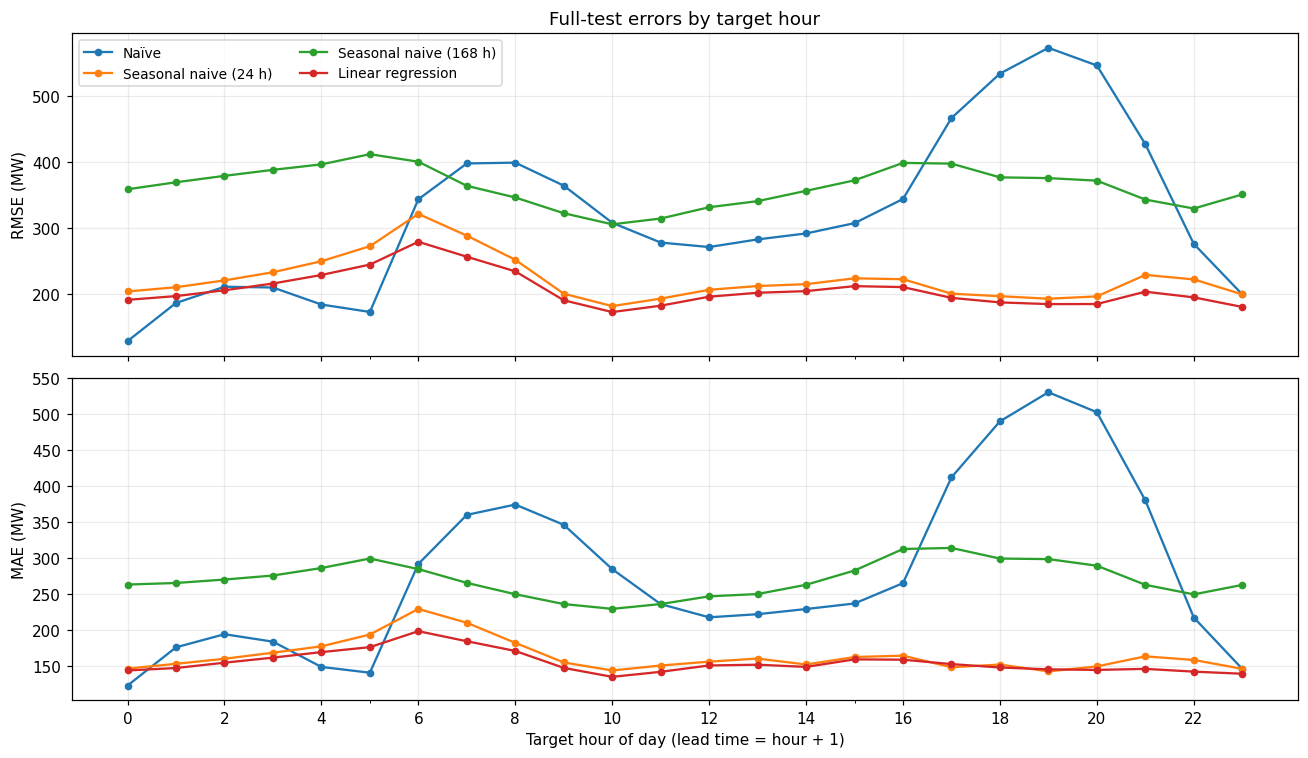

In [179]:
hourly_rmse = pd.DataFrame(index=range(24), columns=forecasts.columns, dtype=float)
hourly_mae = hourly_rmse.copy()
for hour in range(24):
    selected = test_actual.index.hour == hour
    for model in forecasts:
        hourly_rmse.loc[hour, model] = rmse(test_actual.loc[selected], forecasts.loc[selected, model])
        hourly_mae.loc[hour, model] = mae(test_actual.loc[selected], forecasts.loc[selected, model])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
hourly_rmse.plot(ax=axes[0], marker="o", markersize=4)
hourly_mae.plot(ax=axes[1], marker="o", markersize=4, legend=False)
axes[0].set(title="Full-test errors by target hour", ylabel="RMSE (MW)")
axes[0].legend(ncol=2, fontsize=9)
axes[1].set(xlabel="Target hour of day (lead time = hour + 1)", ylabel="MAE (MW)")
axes[1].set_xticks(range(0, 24, 2))
fig.tight_layout()
plt.show()

## 10. Discuss the results

1. Which model has the lowest RMSE, MAE and MAPE? Are the rankings identical?
2. Why is daily persistence flat, while seasonal naïve and linear regression vary within the forecast day?
3. Why is the linear regression model very similar to seasonal naive (24 h)? Which parameters do you need to check?
4. When might the daily benchmark work better than the weekly benchmark, and vice versa?
5. Why is using an earlier observed test value as a later day's lag not data leakage? Would using the preceding test hour be valid for every target in this day-ahead experiment?
6. What do the lag scatter plots and calendar features contribute to the linear model? Which relevant influences are still missing?
7. At which hours are errors largest? Why might RMSE and MAE emphasise different hours?

**Link to the assessment.** The imputation tutorial practises data-quality checks, preserving observed values and comparing reconstructions. This notebook practises available predictors, chronological splitting, fitting, predicting, metrics and grouped errors. Keep these steps visible in your own work; complex helper functions are not required.

### Worked discussion

1. Linear regression has the lowest RMSE, MAE and MAPE. Persistence and weekly seasonal naïve swap positions between the RMSE and MAE/MAPE rankings.
2. Persistence repeats one level. Seasonal naïve copies an hourly profile, while regression combines hour-varying lagged demand.
3. Check `linear_model.coef_` in `X_train.columns` order and `linear_model.intercept_`. Lag 24 has weight **0.774**, versus **0.180** for lag 168, so regression mainly follows the previous day's profile. The intercept and weekend adjustment change its level.
4. Daily copying follows recent changes; weekly copying preserves the matching weekday. Holidays or unusual operation can weaken either benchmark.
5. Earlier test observations are valid once observed at the daily origin. Lag 1 is known only for the first target hour, not the whole day-ahead horizon.
6. Lags capture recurring demand and the weekend flag captures scheduling differences. Weather and holidays remain unmodelled. Other available predictors include target-hour indicators and averages of already observed demand.
7. Linear-regression errors peak around 06:00. RMSE gives large errors more weight than MAE. Hour-of-day and lead-time effects are linked in this experiment.

In [180]:
for metric in comparison.columns:
    print(f"{metric}: best = {comparison[metric].idxmin()}")
    print("  Ranking:", " < ".join(comparison[metric].sort_values().index))

RMSE (MW): best = Linear regression
  Ranking: Linear regression < Seasonal naive (24 h) < Naïve < Seasonal naive (168 h)
MAE (MW): best = Linear regression
  Ranking: Linear regression < Seasonal naive (24 h) < Seasonal naive (168 h) < Naïve
MAPE (%): best = Linear regression
  Ranking: Linear regression < Seasonal naive (24 h) < Seasonal naive (168 h) < Naïve


## 11. Optional extension: one-step-ahead load forecasting

Use the same load series, training/test dates and four methods, but move the forecast origin forward **one hour** instead of one day. At origin $t$, observe $y_t$ and forecast $y_{t+1}$. Once that next observation arrives, move forward and repeat.

Keep the tables indexed by the **target timestamp**, as above. For the row targeting $t+1$, `shift(1)` supplies the current origin observation $y_t$. Persistence now follows the latest hourly observation, and regression can use lag 1 as well as lags 24/168 and the weekend flag. The seasonal-naïve rules do not change.

Fit regression once on the same training period and keep its coefficients fixed. During testing, update lagged **observations** at each hourly origin; do not use a forecast as the next observed value. This is a sequence of one-hour-ahead forecasts, not a recursive forecast of a full day from one origin. No further exploratory plots are needed.

### Create the one-step datasets

Copy the earlier predictors and add `load_lag_1`. Construct it on the complete series before selecting training and test rows. Keep every test target, so the two forecast settings are scored on exactly the same observations.

In [181]:
one_step_features = features.copy()
one_step_features["load_lag_1"] = load_series.shift(1)
ONE_STEP_COLUMNS = ["load_lag_1", "load_lag_24", "load_lag_168", "is_weekend"]

X_train_one_step = one_step_features.loc[TRAIN_START:TRAIN_END, ONE_STEP_COLUMNS].dropna()
y_train_one_step = load_series.loc[X_train_one_step.index]
X_test_one_step = one_step_features.loc[TEST_START:TEST_END, ONE_STEP_COLUMNS]
one_step_origins = pd.Series(test_index - pd.Timedelta(hours=1), index=test_index)
one_step_forecasts = pd.DataFrame(index=test_index)

assert X_train_one_step.index.equals(y_train_one_step.index)
assert X_train_one_step.index.equals(X_train.index)
assert X_test_one_step.index.equals(test_actual.index) and X_test_one_step.notna().all().all()
assert (one_step_origins.to_numpy() < test_index.to_numpy()).all()
print(f"One-step training rows: {len(X_train_one_step):,}; test rows: {len(X_test_one_step):,}.")
print(f"First two hourly origins: {one_step_origins.iloc[0]}, {one_step_origins.iloc[1]}.")

One-step training rows: 6,384; test rows: 2,208.
First two hourly origins: 2007-09-30 23:00:00, 2007-10-01 00:00:00.


### Persistence

At each hourly origin, use the current observation as the next hour's forecast: $\hat y_{t+1\mid t}=y_t$. With target-indexed rows, this is the available lag-1 column.

In [182]:
one_step_forecasts["Naïve"] = X_test_one_step["load_lag_1"]

### Daily seasonal naïve

Copy the target's same-hour observation from 24 hours earlier, just as in the day-ahead experiment.

In [183]:
one_step_forecasts["Seasonal naive (24 h)"] = X_test_one_step["load_lag_24"]

### Weekly seasonal naïve

Copy the target's same hour and weekday from 168 hours earlier. Its forecasts are also unchanged.

In [184]:
one_step_forecasts["Seasonal naive (168 h)"] = X_test_one_step["load_lag_168"]

### Linear regression

Fit a separate LinearRegression model on the four one-step predictors. The extra lag-1 input is available at every hourly origin. Predict the full test table and project negative demand forecasts to zero, as before.

With rows labelled by target $t$, the equation becomes $\hat y_t=\beta_0+\beta_1y_{t-1}+\beta_{24}y_{t-24}+\beta_{168}y_{t-168}+\beta_W I_t$. The additional weight $\beta_1$ describes the latest observed load; the other parameters have the same meanings as above.

In [185]:
one_step_linear_model = LinearRegression()
one_step_linear_model.fit(X_train_one_step, y_train_one_step)
one_step_linear_predictions = pd.Series(
    one_step_linear_model.predict(X_test_one_step), index=test_index,
)
one_step_forecasts["Linear regression"] = one_step_linear_predictions.clip(lower=0)

### Estimate errors on the full test set

Reuse `rmse`, `mae` and `mape`. Score all four methods using actual demand first and forecasts second. The side-by-side table compares both settings on the same 2,208 test hours.

In [186]:
assert one_step_forecasts.index.equals(test_actual.index)
assert np.isfinite(one_step_forecasts.to_numpy()).all()
one_step_rows = []
for model in one_step_forecasts:
    prediction = one_step_forecasts[model]
    one_step_rows.append({"Model": model, "RMSE (MW)": rmse(test_actual, prediction),
                          "MAE (MW)": mae(test_actual, prediction),
                          "MAPE (%)": mape(test_actual, prediction)})
one_step_comparison = pd.DataFrame(one_step_rows).set_index("Model")
display(one_step_comparison.round(3))

horizon_comparison = pd.concat({"Day-ahead": comparison, "One-step ahead": one_step_comparison}, axis=1)
display(horizon_comparison.round(3))

,RMSE (MW),MAE (MW),MAPE (%)
Model,,,
Naïve,126.632,95.696,4.420
Seasonal naive (24 h),224.468,163.991,7.346
Seasonal naive (168 h),363.382,270.876,12.122
Linear regression,112.200,85.273,3.915


Day-ahead                   One-step ahead           \
                       RMSE (MW) MAE (MW) MAPE (%)      RMSE (MW) MAE (MW)   
Model                                                                        
Naïve                    342.700  279.872   12.607        126.632   95.696   
Seasonal naive (24 h)    224.468  163.991    7.346        224.468  163.991   
Seasonal naive (168 h)   363.382  270.876   12.122        363.382  270.876   
Linear regression        207.330  155.355    6.990        112.200   85.273   

                                 
                       MAPE (%)  
Model                            
Naïve                     4.420  
Seasonal naive (24 h)     7.346  
Seasonal naive (168 h)   12.122  
Linear regression         3.915

### Visualise performance

Use the same test week for both settings, with matching axes. The metrics above use the full test period, not only this week.

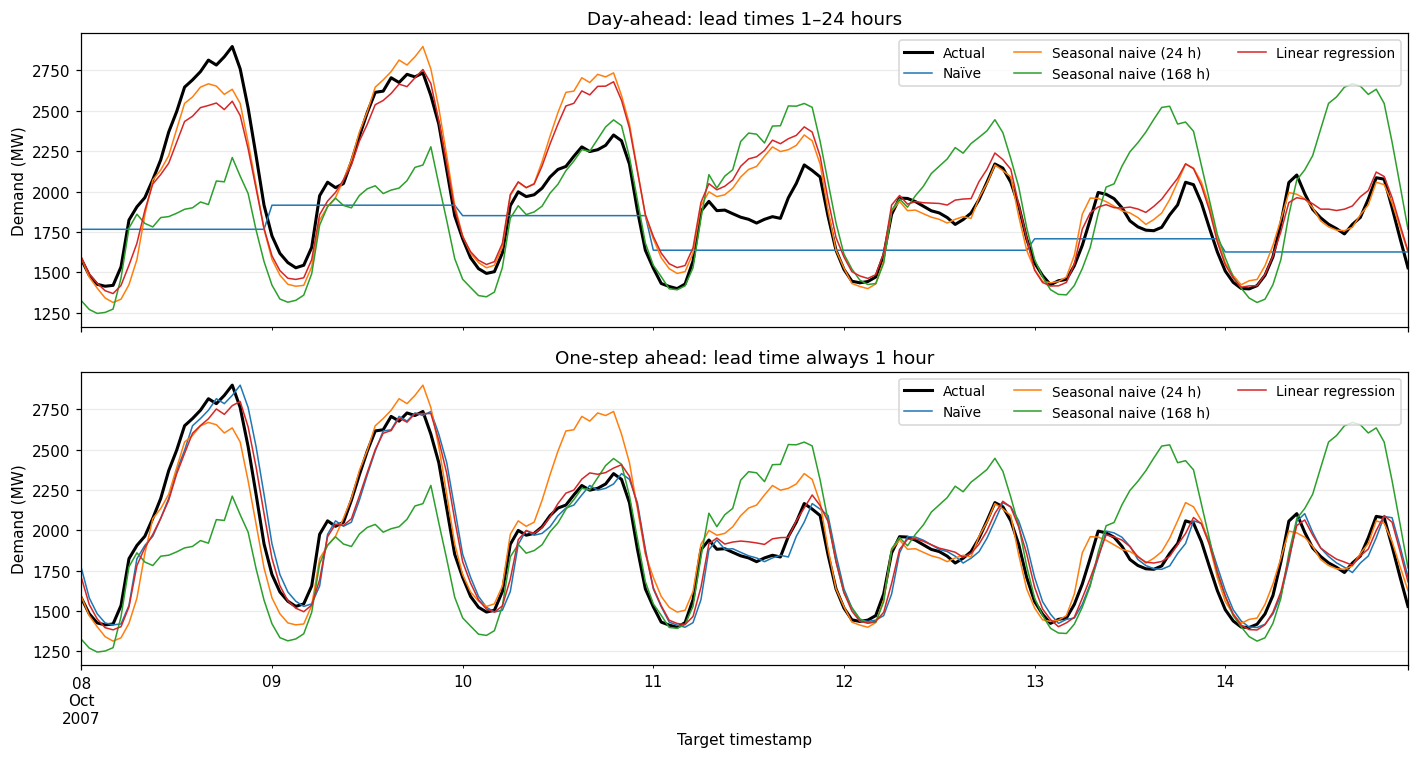

In [187]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, sharey=True)
for ax, title, prediction_table in [
    (axes[0], "Day-ahead: lead times 1–24 hours", forecasts),
    (axes[1], "One-step ahead: lead time always 1 hour", one_step_forecasts),
]:
    test_actual.loc[PLOT_START:PLOT_END].plot(ax=ax, color="black", linewidth=2, label="Actual")
    prediction_table.loc[PLOT_START:PLOT_END].plot(ax=ax, linewidth=1)
    ax.set(title=title, ylabel="Demand (MW)")
    ax.legend(ncol=3, fontsize=9)
axes[0].set_xlabel("")
axes[1].set_xlabel("Target timestamp")
fig.tight_layout()
plt.show()

**Compare the forecast horizons:** Using the table and plots, how do persistence and linear regression change from day-ahead to one-step-ahead forecasting, and why do the seasonal-naïve scores stay the same? Explain why observed lag 1 is valid here but unavailable for most targets in a full day-ahead forecast.

**Worked response:** Persistence and regression improve because each forecast can use the observation from only one hour earlier. Seasonal naïve uses the same lag-24/168 lags in both settings, so its forecasts and scores are identical. The results highlight that one-hour ahead forecasting is an easier task than day-ahead forecasting.